In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib
import gradio as gr

In [2]:
# ==================== LOAD & EXPLORE DATA ====================
df = pd.read_csv("/content/Diabetes_dataset.csv")

In [3]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df.shape

(253680, 22)

In [6]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [7]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [8]:
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [9]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


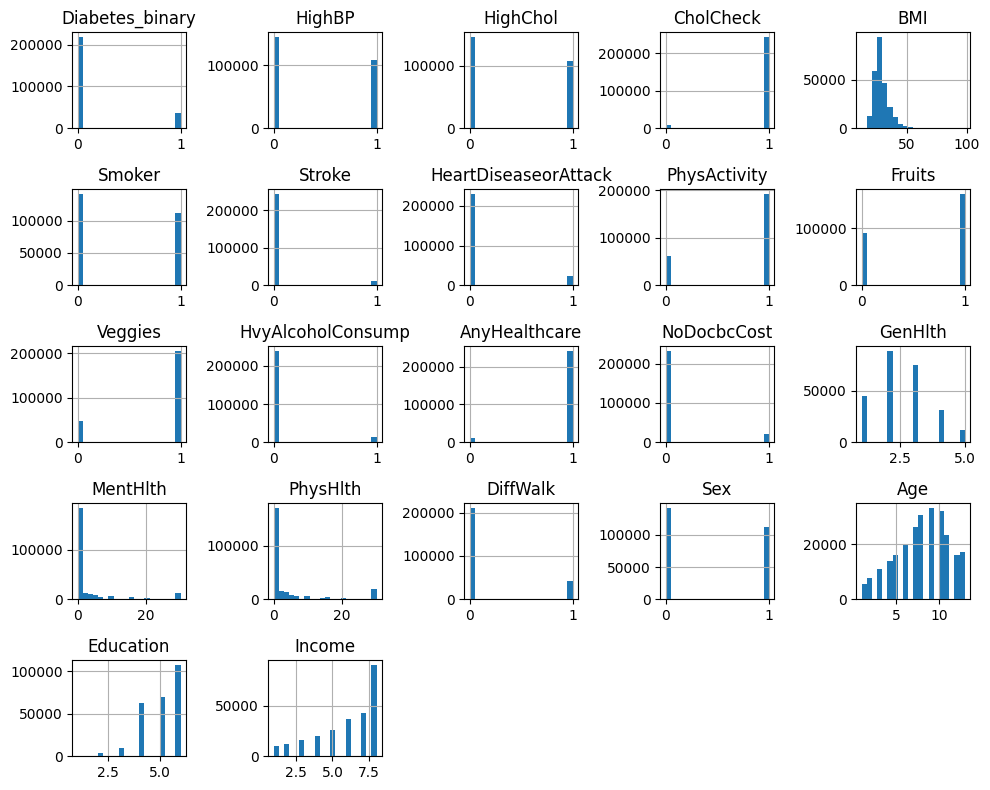

In [10]:
num_cols = df.select_dtypes(include = [np.number]).columns
df[num_cols].hist(figsize = (10,8), bins = 20)
plt.tight_layout()
plt.show()

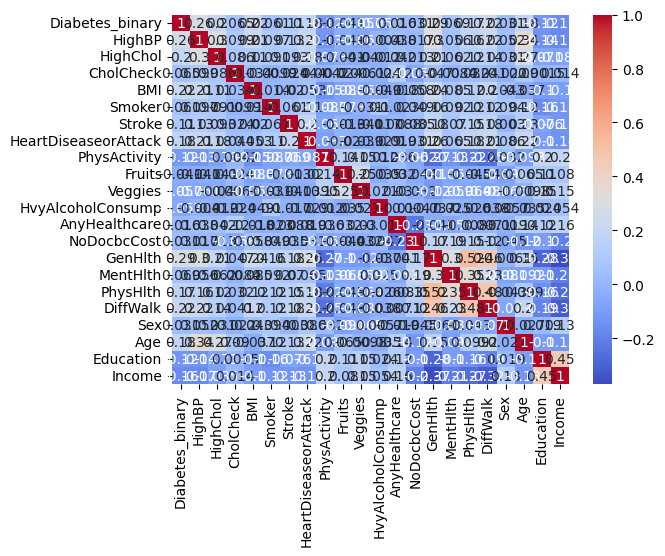

In [11]:
num_df = df.select_dtypes(include = [np.number])
sns.heatmap(num_df.corr(),annot = True, cmap = 'coolwarm')
plt.show()

In [12]:
for col in df.select_dtypes(include = 'object').columns:
  print(col, df[col].unique())

In [13]:
print("=== Diabetes Dataset Summary ===")
print(f"Healthy people: {sum(df['Diabetes_binary'] == 0)}")
print(f"Diabetic people: {sum(df['Diabetes_binary'] == 1)}")

=== Diabetes Dataset Summary ===
Healthy people: 218334
Diabetic people: 35346


In [14]:
# ==================== PREPROCESSING ====================
df_clean = df.copy()
df_clean = df_clean.drop(['AnyHealthcare', 'CholCheck', 'Stroke', 'HvyAlcoholConsump','NoDocbcCost'], axis=1)

In [15]:
# ==================== TRAIN-TEST SPLIT ====================
x = df_clean.drop('Diabetes_binary', axis=1)
y = df_clean['Diabetes_binary']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Class distribution Before SMOTE: {y_train.value_counts()}")


 Class distribution Before SMOTE: Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64


In [16]:
# ==================== APPLY SMOTE ====================
print("\nApplying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print(f"After SMOTE: {y_train_resampled.value_counts()}")


Applying SMOTE to balance training data...
After SMOTE: Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


In [17]:
# ==================== SCALING ====================
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_resampled)
x_test_scaled = scaler.transform(x_test)

In [18]:
# ==================== RANDOM FOREST MODEL ====================
print("\n--- Training Random Forest ---")

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_model.fit(x_train_scaled, y_train_resampled)


--- Training Random Forest ---


RandomForestClassifier(n_jobs=-1, random_state=42)

In [19]:
# ================== PREDICTIONS & EVALUATION ==================
y_pred = rf_model.predict(x_test_scaled)
y_pred_proba = rf_model.predict_proba(x_test_scaled)

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92     43667
         1.0       0.45      0.21      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.66      0.58      0.60     50736
weighted avg       0.82      0.85      0.83     50736

Accuracy: 0.8540


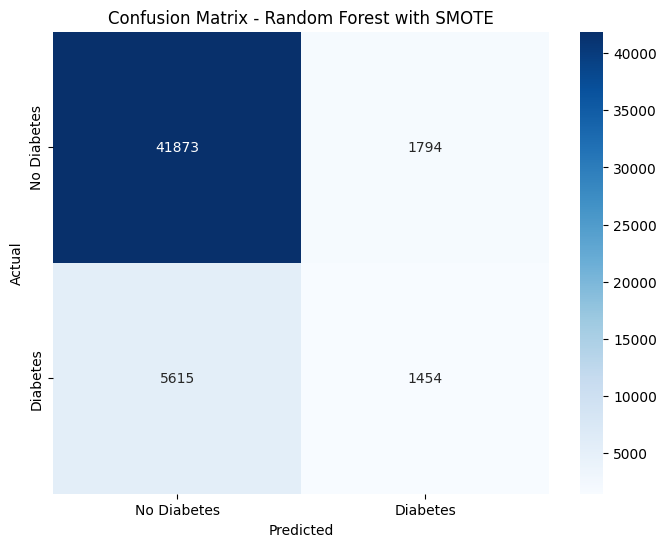

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest with SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [21]:
# ==================== FEATURE IMPORTANCE ====================
print("\n--- FEATURE IMPORTANCE ANALYSIS ---")
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending = False)

# Display top 10 features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


--- FEATURE IMPORTANCE ANALYSIS ---

Top 10 Most Important Features:
      Feature  Importance
0      HighBP    0.153068
8     GenHlth    0.148455
1    HighChol    0.114519
2         BMI    0.104015
13        Age    0.085488
15     Income    0.057009
11   DiffWalk    0.047642
14  Education    0.042396
12        Sex    0.038981
10   PhysHlth    0.035579


In [22]:
# ==================== SAVE MODEL OBJECTS ====================
joblib.dump(rf_model, "rf_diabetes.pkl") #prediction logic
joblib.dump(scaler, "scaler.pkl") #correct scaling
joblib.dump(x.columns.tolist(), "feature_names.pkl") #correct feature mapping

['feature_names.pkl']

In [23]:
# ==================== GRADIO PREDICTION FUNCTION ====================
rf_model = joblib.load("rf_diabetes.pkl")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

def predict_simple(high_bp, high_chol, bmi, age):
    # Default all features to 0
    feature_dict = {feature: 0 for feature in feature_names}

    # Fill selected features
    feature_dict['HighBP'] = high_bp
    feature_dict['HighChol'] = high_chol
    feature_dict['BMI'] = bmi
    feature_dict['Age'] = age

    input_array = np.array([[feature_dict[f] for f in feature_names]])
    input_scaled = scaler.transform(input_array)

    prob = rf_model.predict_proba(input_scaled)[0][1]

    if prob < 0.25:
        risk = "Low Risk"
    elif prob < 0.5:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    return f"Probability of Diabetes: {prob:.2f} \nRisk Level: {risk}"

In [24]:
# ==================== GRADIO INTERFACE ====================
demo = gr.Interface(
    fn=predict_simple,
    inputs=[
        gr.Radio([1, 0], label="High Blood Pressure (1=Yes, 0=No)"),
        gr.Radio([1, 0], label="High Cholesterol (1=Yes, 0=No)"),
        gr.Slider(15, 50, value=25, label="BMI"),
        gr.Slider(1, 13, value=7, label="Age Group")
    ],
    outputs="text",
    title="Diabetes Risk Predictor (Random Forest)"
)
demo.launch(debug=True)

   # Age_1_to_13
   # 1: "18-24 years",
   # 2: "25-29 years",
   # 3: "30-34 years",
   # 4: "35-39 years",
   # 5: "40-44 years",
   # 6: "45-49 years",
   # 7: "50-54 years",
   # 8: "55-59 years",
   # 9: "60-64 years",
   # 10: "65-69 years",
   # 11: "70-74 years",
   # 12: "75-79 years",
   # 13: "80+ years"

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://97404c9bfbf3fd1dd1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://97404c9bfbf3fd1dd1.gradio.live
